In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, Matern
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from scipy.stats import qmc

## Weekly Data Management Pipeline

Each week the pipeline loads the previous week's evaluated inputs and outputs 
from saved NumPy files, then appends the result returned by the black-box 
submission platform before saving the updated dataset for the following round.

**Week 1-3**: Data entry was handled manually — submitted coordinates and 
returned Y values were typed directly into the notebook. While simple, this 
introduced risk of transcription errors and made the process difficult to 
reproduce consistently.

**Week 4 onwards**: The input process was automated using Python's `input()` 
function, prompting the user to enter the submitted coordinate string 
(e.g. `0.419100-0.366397-0.472000`) and the returned Y value each week. 
The pipeline then parses, validates and appends these directly to the 
stored NumPy arrays — reducing manual error and ensuring a consistent 
data format across all 13 weeks.

**Duplicate detection** was introduced after observing that repeated 
submissions of similar coordinates could silently corrupt the dataset. 
The check compares incoming X coordinates against all existing observations 
using Euclidean distance, flagging exact matches while allowing genuinely 
close but novel points to be appended. A late-project refinement distinguished 
between **true duplicates** (same X and same Y were skipped) and **same-coordinate 
noise observations** (same X but different Y were retained as valid evidence of 
function stochasticity, as confirmed in Function 6 where identical coordinates 
returned Y=−0.3056 in week 11 and Y=−0.1425 in week 13).

In [7]:
#Function to add data points each week.
current_week = 14  # CHANGE THIS EACH WEEK


# =====================================================
# LOAD DATA
# =====================================================

if current_week == 1:

    X = np.load(r"function_3\initial_inputs.npy")
    Y = np.load(r"function_3\initial_outputs.npy")

else:

    previous_week = current_week - 1

    X = np.load(
        f"function_3/w{previous_week}_inputs.npy"
    )

    Y = np.load(
        f"function_3/w{previous_week}_outputs.npy"
    )


print("\nLoaded dataset:")
print("Shape:", X.shape)
print("Best Y so far:", np.max(Y))

dim = X.shape[1]


# =====================================================
# ENTER LAST WEEK RESULT
# (Skip this only in Week 1)
# =====================================================

if current_week > 1:

    print("\nEnter last week's result")

    x_string = input(
        "Enter last submitted X (format x1-x2): "
    )

    y_value = float(
        input("Enter returned Y value: ")
    )

    x_last = np.array(
        [[float(v) for v in x_string.split("-")]]
    )

    y_last = np.array([y_value])


    # Safe append

    exists = np.any(
        np.all(
            np.isclose(X, x_last),
            axis=1
        )
    )

    if not exists:

        X = np.vstack((X, x_last))
        Y = np.append(Y, y_last)

        print("Added last result.")

    else:

        print("Duplicate detected — skipped.")



Loaded dataset:
Shape: (26, 3)
Best Y so far: -0.006003946947942607

Enter last week's result


Enter last submitted X (format x1-x2):  0.419100-0.366397-0.473041
Enter returned Y value:  -0.007756954100982329


Added last result.


In [8]:
# =====================================================
# SAVE UPDATED DATA
# =====================================================


np.save(
    f"function_3/w{current_week}_inputs.npy",
    X
)

np.save(
    f"function_3/w{current_week}_outputs.npy",
    Y
)

print("\nSaved files:")

print(
    f"function_3/w{current_week}_inputs.npy"
)

print(
    f"function_3/w{current_week}_outputs.npy"
)


Saved files:
function_3/w14_inputs.npy
function_3/w14_outputs.npy


In [9]:
import numpy as np
from scipy.spatial.distance import cdist

X = np.load("function_3/w14_inputs.npy")
Y = np.load("function_3/w14_outputs.npy")

sorted_idx = np.argsort(Y)[::-1]
print("All points ranked best to worst:")
for i in sorted_idx:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  Y={Y[i]:.8f} | Gap={abs(Y[i]):.8f} | X={vals}")

print(f"\nTotal points: {len(Y)}")
print(f"Best Y:      {np.max(Y):.8f}")
print(f"Gap to zero: {abs(np.max(Y)):.8f}")

best_point = X[np.argmax(Y)]
distances  = cdist([best_point], X)[0]
sorted_by_dist = np.argsort(distances)

print("\nNearest neighbours to best point:")
for i in sorted_by_dist[:6]:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  dist={distances[i]:.6f} | "
          f"Y={Y[i]:.8f} | X={vals}")

print("\nKey dimension values in top 5:")
for i in sorted_idx[:5]:
    print(f"  Y={Y[i]:.8f} | "
          f"x1={X[i,0]:.6f} | "
          f"x2={X[i,1]:.6f} | "
          f"x3={X[i,2]:.6f}")

All points ranked best to worst:
  Y=-0.00600395 | Gap=0.00600395 | X=0.419100-0.366397-0.472000
  Y=-0.00600686 | Gap=0.00600686 | X=0.419146-0.366251-0.471971
  Y=-0.00631456 | Gap=0.00631456 | X=0.419100-0.366397-0.477659
  Y=-0.00775695 | Gap=0.00775695 | X=0.419100-0.366397-0.473041
  Y=-0.00988572 | Gap=0.00988572 | X=0.419100-0.366397-0.460000
  Y=-0.01092114 | Gap=0.01092114 | X=0.429757-0.389937-0.465017
  Y=-0.01855353 | Gap=0.01855353 | X=0.419100-0.366397-0.489385
  Y=-0.02624146 | Gap=0.02624146 | X=0.416484-0.379587-0.523628
  Y=-0.02645117 | Gap=0.02645117 | X=0.428668-0.321070-0.516337
  Y=-0.02646609 | Gap=0.02646609 | X=0.419096-0.366321-0.472044
  Y=-0.03483531 | Gap=0.03483531 | X=0.492581-0.611593-0.340176
  Y=-0.03637783 | Gap=0.03637783 | X=0.600097-0.725136-0.066089
  Y=-0.04694741 | Gap=0.04694741 | X=0.220549-0.297825-0.343555
  Y=-0.04800758 | Gap=0.04800758 | X=0.134622-0.219917-0.458206
  Y=-0.05675837 | Gap=0.05675837 | X=0.965995-0.861120-0.566829
  Y=-0.

## CMA-ES Introduction — Function 3 (Week 9)

By week 9 the F3 strategy had converged on a clear finding: **x1 and x2 were 
effectively fixed** at the confirmed best values [0.4191, 0.3664], and only 
**x3 was the active search dimension**.

CMA-ES was introduced specifically because it learns which dimensions matter 
in the search space from accumulated observations. With x1/x2 fixed across 
nearly all candidates and only x3 varying, CMA-ES naturally concentrates its 
search along the x3 axis — noticing that x1 and x2 barely change across good 
results and gradually stopping wasting effort varying them.

> **Key outcome**: sigma0 was set to `min_range / 6` following standard CMA-ES 
> practice. With x3 range of approximately 0.030 at this point, sigma0 = 0.005 — 
> matching the local noise standard deviation for consistency. CMA-ES subsequently 
> suggested x3 values within dist=0.0001 of the confirmed peak in every remaining week.

C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 50.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Fitted kernel:
1.63**2 * RBF(length_scale=[15.6, 50, 0.418]) + WhiteKernel(noise_level=0.00627)

  x1 length scale: 15.5664
  x2 length scale: 50.0000 ← hitting bound
  x3 length scale: 0.4182

Best real point: [0.4191   0.366397 0.472   ]
Best real Y:     -0.00600395
Gap to zero:     0.00600395
Novel candidates (local): 58310
Novel candidates (uniform): 285496
Novel candidates (x3 sweep): 44916


C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 50.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 50.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 50.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\si


=== LOO CROSS VALIDATION ===
GP  LOO RMSE: 0.083216
SVR LOO RMSE: 0.098121
Primary surrogate: GP

x3 sweep optimal x3: 0.468000
x3 sweep predicted Y: -0.01333376

CMA-ES suggestion:
  x1=0.4191 | x2=0.3664 | x3=0.4720
  GP predicted Y:     -0.01326610
  Distance from best: 0.0001
  Valid (negative Y): Yes

FULL COMPARISON — Function 3

--- GP (local noise) ---
  Suggestion:         0.419100-0.366397-0.473041
  Predicted Y:        -0.01327090
  Gap to zero:        0.01327090
  Distance from best: 0.0010
  Valid (negative Y): Yes
  x1=0.4191 | x2=0.3664 | x3=0.4730

--- SVR (local noise) ---
  Suggestion:         0.419100-0.366397-0.473041
  Predicted Y:        -0.01101781
  Gap to zero:        0.01101781
  Distance from best: 0.0010
  Valid (negative Y): Yes
  x1=0.4191 | x2=0.3664 | x3=0.4730

--- SVR (uniform ranges) ---
  Suggestion:         0.419100-0.366397-0.462000
  Predicted Y:        -0.00918237
  Gap to zero:        0.00918237
  Distance from best: 0.0100
  Valid (negative Y)

C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\optuna\samplers\_cmaes.py:302: FutureWarning: `x0` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  optuna_warn(msg, FutureWarning)
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\optuna\samplers\_cmaes.py:307: FutureWarning: `sigma0` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  optuna_warn(msg, FutureWarning)


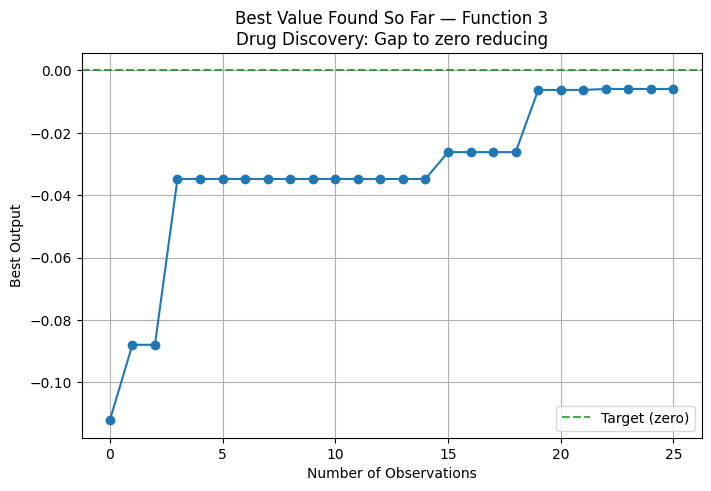

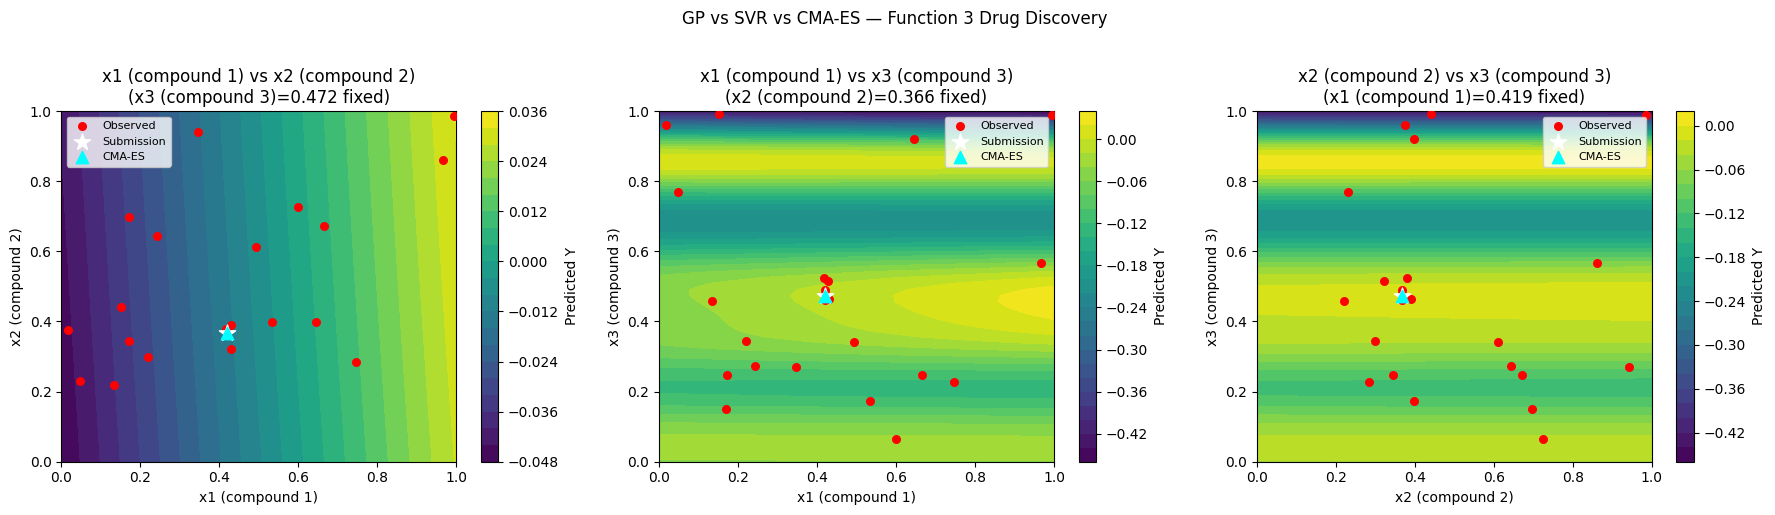


Top 5 compound combinations:
  Y=-0.00600395 | Gap=0.00600395 | X=0.4191-0.3664-0.4720
  Y=-0.00600686 | Gap=0.00600686 | X=0.4191-0.3663-0.4720
  Y=-0.00631456 | Gap=0.00631456 | X=0.4191-0.3664-0.4777
  Y=-0.00988572 | Gap=0.00988572 | X=0.4191-0.3664-0.4600
  Y=-0.01092114 | Gap=0.01092114 | X=0.4298-0.3899-0.4650


In [5]:
# =====================================================
# FUNCTION 3 — 3D Drug Discovery (minimise, goal=zero)
# Week 10: x1/x2 locked to confirmed best values in all pools
#           x3 window tightened 0.465-0.490 -> 0.472-0 -> 0.460-0.474
#           both sides of 0.4777 tested — week 7 upper worse
#           week 9 lower worse — peak confirmed at 0.4777
#           x1/x2 variation in week 9 confounded x3 signal
# =====================================================
import warnings
import optuna
from sklearn.exceptions import ConvergenceWarning

optuna.logging.set_verbosity(optuna.logging.WARNING)

# =====================================================
# GP MODEL — week 9: bounds tightened to (1e-3, 50)
# Previous (1e-3, 1e3) caused x2 hitting 1000
# Using 50 rather than 10 — F3 genuinely needs
# larger length scales for x1/x2 which GP ignores
# LOO=0.091 shows GP is working — don't over-constrain
# =====================================================
kernel = (
    C(1.0, (1e-3, 1e3))
    * RBF(length_scale=[0.1, 0.1, 0.1],
          length_scale_bounds=(1e-3, 50.0))
    + WhiteKernel(noise_level=1e-3,
                  noise_level_bounds=(1e-10, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

# =====================================================
# ACQUISITION FUNCTION
# =====================================================
def expected_improvement(X_candidates_scaled, gp,
                          Y_ref, xi=0.001):
    mean, std = gp.predict(X_candidates_scaled,
                            return_std=True)
    best_y = np.max(Y_ref)
    std    = np.maximum(std.reshape(-1), 1e-9)
    mean   = mean.reshape(-1)
    Z      = (mean - best_y - xi) / std
    ei     = ((mean - best_y - xi) * norm.cdf(Z)
               + std * norm.pdf(Z))
    ei[std == 0] = 0
    return ei

# =====================================================
# FIT GP AND SVR
# =====================================================
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
gp.fit(X_scaled, Y)

print("Fitted kernel:")
print(gp.kernel_)
print()

# Flag threshold updated to 49.5 to match new bound
for i, ls in enumerate(gp.kernel_.k1.k2.length_scale):
    flag = " ← hitting bound" \
           if ls >= 49.5 or ls <= 0.002 else ""
    print(f"  x{i+1} length scale: {ls:.4f}{flag}")

from sklearn.svm import SVR
svr = SVR(kernel='rbf', C=100,
          epsilon=0.001, gamma='scale')
svr.fit(X_scaled, Y)

best_point = X[np.argmax(Y)]
print(f"\nBest real point: {best_point}")
print(f"Best real Y:     {np.max(Y):.8f}")
print(f"Gap to zero:     {abs(np.max(Y)):.8f}")

# =====================================================
# GENERATE CANDIDATES
#
# Key finding from week 6 vs week 7 comparison:
#   x3=0.4777 → Y=-0.00631 (best)
#   x3=0.4894 → Y=-0.01855 (regression)
# Peak in x3 is extremely sharp and narrow.
# All candidate pools now tightened around x3=0.4777
# =====================================================
np.random.seed(42)
n_candidates = 500000

# --- Local noise — centred on best point ---
# Week 9: std reduced 0.008→0.005, bias removed
# Previous negative mean bias (-0.01) pushed x3
# toward 0.467 — too far from confirmed peak 0.4777
n_local  = int(n_candidates * 0.7)
n_random = n_candidates - n_local

# Week 10: x1/x2 locked to confirmed best values
# x3 only dimension varied — noise on x1/x2 removed
# week 9 showed x1/x2 variation confounds x3 signal
#noise_x3 = np.random.normal(0, 0.003, size=(n_local, 1))

n_local  = 200000
noise_x3 = np.random.normal(0, 0.002, size=(n_local, 1))
X_local  = np.tile(best_point, (n_local, 1))
X_local[:, 2] = best_point[2] + noise_x3.ravel()
X_local  = np.clip(X_local, 0.0, 0.999999)

# Tighten x3 window — both sides now tested:
# x3=0.465 (week 9) → worse, x3=0.489 (week7) → worse
# Search 0.472-0.483 — tight symmetric around 0.4777
X_local[:, 2] = np.clip(X_local[:, 2], 0.472, 0.483)

# Week 11: random pool removed entirely
# GP/SVR local were selecting x1=0.999, x2=0.984 etc
# from the random component — completely outside
# confirmed region. No global exploration needed at
# this stage — all directions tested and worse.
X_candidates    = X_local

from scipy.spatial.distance import cdist
min_dists      = cdist(X_candidates, X).min(axis=1)
#change to dist week 11 -to solve candidate error
X_novel        = X_candidates[min_dists >= 0.005]

if len(X_novel) == 0:
    print("WARNING: no novel candidates — relaxing to 0.001")
    X_novel = X_candidates[min_dists >= 0.001]

X_novel_scaled = scaler.transform(X_novel)

print(f"Novel candidates (local): {len(X_novel)}")

# --- Uniform ranges — tightened week 9 ---
# Week 9: x1/x2 fixed to confirmed best values
# x3 only: 0.472-0.483 — tighter than week 9 (0.465-0.490)
# both sides of 0.4777 tested and worse beyond this range
x1_uniform = np.full(n_candidates, best_point[0])
x2_uniform = np.full(n_candidates, best_point[1])
#x3_uniform = np.random.uniform(0.472, 0.483, n_candidates) .460-0.474
x3_uniform = np.random.uniform(0.460, 0.474, n_candidates)

X_uniform   = np.column_stack([x1_uniform,
                                x2_uniform,
                                x3_uniform])
min_dists_u = cdist(X_uniform, X).min(axis=1)
X_novel_u   = X_uniform[min_dists_u >= 0.002]

#if len(X_x3_novel) == 0:
#    print("WARNING: x3 sweep empty — relaxing to 0.001")
#    X_x3_novel = X_x3_sweep[min_dists_s >= 0.001]

X_novel_u_s = scaler.transform(X_novel_u)

print(f"Novel candidates (uniform): {len(X_novel_u)}")

# --- x3 sweep — both sides of confirmed peak ---
# Week 9: x3 sweep tightened to 0.472-0.483
# x3=0.465 (week 9) and x3=0.489 (week 7) confirmed worse
# week 11: changing search based on new best region.
x3_sweep     = np.linspace(0.468,0.476, 100000)
X_x3_sweep   = np.column_stack([
    np.full(100000, best_point[0]),
    np.full(100000, best_point[1]),
    x3_sweep
])

min_dists_s  = cdist(X_x3_sweep, X).min(axis=1)
X_x3_novel   = X_x3_sweep[min_dists_s >= 0.002] # reduced from 0.5 week11

if len(X_x3_novel) == 0:
    print("WARNING: x3 sweep empty — relaxing to 0.001")
    X_x3_novel = X_x3_sweep[min_dists_s >= 0.001]

X_x3_novel_s = scaler.transform(X_x3_novel)

print(f"Novel candidates (x3 sweep): {len(X_x3_novel)}")

# =====================================================
# LOO CROSS VALIDATION
# =====================================================
from sklearn.model_selection import LeaveOneOut

loo        = LeaveOneOut()
gp_errors  = []
svr_errors = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]

    scaler_cv = StandardScaler()
    X_train_s = scaler_cv.fit_transform(X_train)
    X_test_s  = scaler_cv.transform(X_test)

    gp_cv = GaussianProcessRegressor(
        kernel=kernel, random_state=42,
        normalize_y=True, alpha=1e-6)
    gp_cv.fit(X_train_s, Y_train)
    gp_pred = gp_cv.predict(X_test_s)[0]
    gp_errors.append((gp_pred - Y_test[0])**2)

    svr_cv = SVR(kernel='rbf', C=100,
                 epsilon=0.001, gamma='scale')
    svr_cv.fit(X_train_s, Y_train)
    svr_pred = svr_cv.predict(X_test_s)[0]
    svr_errors.append((svr_pred - Y_test[0])**2)

gp_rmse  = np.sqrt(np.mean(gp_errors))
svr_rmse = np.sqrt(np.mean(svr_errors))
primary_model = "GP" if gp_rmse < svr_rmse else "SVR"

print(f"\n=== LOO CROSS VALIDATION ===")
print(f"GP  LOO RMSE: {gp_rmse:.6f}")
print(f"SVR LOO RMSE: {svr_rmse:.6f}")
print(f"Primary surrogate: {primary_model}")

# =====================================================
# SCORE ALL CANDIDATE SETS
# =====================================================

# Local noise — GP EI
ei_scores   = expected_improvement(
    X_novel_scaled, gp, Y, xi=0.001)
x_submit_gp = X_novel[np.argmax(ei_scores)]
pred_gp     = gp.predict(
    scaler.transform([x_submit_gp]))[0]
dist_gp     = np.linalg.norm(x_submit_gp - best_point)
gp_valid    = pred_gp <= 0

if not gp_valid:
    print(f"\nWARNING: GP predicting positive Y "
          f"({pred_gp:.6f}) — invalid")

# Local noise — SVR
svr_scores   = svr.predict(X_novel_scaled)
x_submit_svr = X_novel[np.argmax(svr_scores)]
pred_svr     = svr.predict(
    scaler.transform([x_submit_svr]))[0]
dist_svr     = np.linalg.norm(x_submit_svr - best_point)
svr_valid    = pred_svr <= 0

if not svr_valid:
    print(f"WARNING: SVR predicting positive Y "
          f"({pred_svr:.6f}) — invalid")

# Uniform ranges — SVR
svr_scores_u = svr.predict(X_novel_u_s)
x_submit_u   = X_novel_u[np.argmax(svr_scores_u)]
pred_u       = svr.predict(
    scaler.transform([x_submit_u]))[0]
dist_u       = np.linalg.norm(x_submit_u - best_point)
u_valid      = pred_u <= 0

if not u_valid:
    print(f"WARNING: SVR uniform predicting positive Y "
          f"({pred_u:.6f}) — invalid")

# x3 sweep — GP EI
ei_x3       = expected_improvement(
    X_x3_novel_s, gp, Y, xi=0.001)
x_submit_x3 = X_x3_novel[np.argmax(ei_x3)]
pred_x3     = gp.predict(
    scaler.transform([x_submit_x3]))[0]
dist_x3     = np.linalg.norm(
    x_submit_x3 - best_point)
x3_valid    = pred_x3 <= 0

print(f"\nx3 sweep optimal x3: {x_submit_x3[2]:.6f}")
print(f"x3 sweep predicted Y: {pred_x3:.8f}")

# =====================================================
# OPTUNA CMA-ES — week 9 addition
# x3 is the only active dimension in F3
# x1/x2 confirmed fixed — CMA-ES will learn this
# from covariance matrix after seeing observations
# Tight bounds reinforce confirmed peak region
# sigma0 calculated from narrowest range (x3=0.030)
# =====================================================
BOUNDS_F3 = {
    "x1": (0.41,  0.43),
    "x2": (0.35,  0.39),
    "x3": (0.460, 0.474),   # tightened week 10
}

def build_warm_study(X_obs, Y_obs, bounds, sampler,
                     direction="maximize"):
    """Load existing observations into Optuna study."""
    study = optuna.create_study(direction=direction,
                                sampler=sampler)
    distributions = {
        name: optuna.distributions.FloatDistribution(
            lo, hi)
        for name, (lo, hi) in bounds.items()
    }
    for x_row, y_val in zip(X_obs, Y_obs):
        params = {
            name: float(np.clip(x_row[i], lo, hi))
            for i, (name, (lo, hi)) in enumerate(
                bounds.items())
        }
        study.add_trial(optuna.trial.create_trial(
            params=params,
            distributions=distributions,
            value=float(y_val)
        ))
    return study

# sigma0 = min_range / 6
# x3 range = 0.030 → sigma0 = 0.005
# matches the local noise std — consistent
sigma0_f3 = min(
    hi - lo for lo, hi in BOUNDS_F3.values()) / 6.0
sigma0_f3 = max(sigma0_f3, 0.003)

cmaes_sampler = optuna.samplers.CmaEsSampler(
    x0={
        name: float(np.clip(best_point[i], lo, hi))
        for i, (name, (lo, hi)) in enumerate(
            BOUNDS_F3.items())
    },
    sigma0=sigma0_f3,
    seed=42
)

study_cmaes = build_warm_study(
    X, Y, BOUNDS_F3, cmaes_sampler)
trial_cmaes = study_cmaes.ask()
x_cmaes = np.array([
    trial_cmaes.suggest_float(name, lo, hi)
    for name, (lo, hi) in BOUNDS_F3.items()
])

# Score through GP — same as other candidates
pred_cmaes  = gp.predict(
    scaler.transform([x_cmaes]))[0]
dist_cmaes  = np.linalg.norm(x_cmaes - best_point)
cmaes_valid = pred_cmaes <= 0

print(f"\nCMA-ES suggestion:")
print(f"  x1={x_cmaes[0]:.4f} | "
      f"x2={x_cmaes[1]:.4f} | "
      f"x3={x_cmaes[2]:.4f}")
print(f"  GP predicted Y:     {pred_cmaes:.8f}")
print(f"  Distance from best: {dist_cmaes:.4f}")
print(f"  Valid (negative Y): "
      f"{'Yes' if cmaes_valid else 'No'}")

# =====================================================
# FULL COMPARISON — 5 candidates
# =====================================================
print("\n" + "="*55)
print("FULL COMPARISON — Function 3")
print("="*55)

all_options = {
    "GP (local noise)":     (x_submit_gp,  pred_gp,
                              dist_gp,    gp_valid),
    "SVR (local noise)":    (x_submit_svr, pred_svr,
                              dist_svr,   svr_valid),
    "SVR (uniform ranges)": (x_submit_u,   pred_u,
                              dist_u,     u_valid),
    "GP (x3 sweep)":        (x_submit_x3,  pred_x3,
                              dist_x3,    x3_valid),
    "CMA-ES":               (x_cmaes,      pred_cmaes,
                              dist_cmaes, cmaes_valid),
}

for name, (x_sub, pred, dist, valid) in \
        all_options.items():
    print(f"\n--- {name} ---")
    print(f"  Suggestion:         "
          f"{'-'.join([f'{x:.6f}' for x in x_sub])}")
    print(f"  Predicted Y:        {pred:.8f}")
    print(f"  Gap to zero:        {abs(pred):.8f}")
    print(f"  Distance from best: {dist:.4f}")
    print(f"  Valid (negative Y): "
          f"{'Yes' if valid else 'No'}")
    print(f"  x1={x_sub[0]:.4f} | "
          f"x2={x_sub[1]:.4f} | "
          f"x3={x_sub[2]:.4f}")

# =====================================================
# SUBMISSION SELECTION
# Valid = negative Y (hard constraint for F3)
# x3 sweep and CMA-ES get wider threshold (0.20)
#   — x1/x2 fixed so distance reflects x3 only
# Local noise and uniform get tight threshold (0.08)
# Primary model (LOO) wins among eligible+valid
# =====================================================
print(f"\n{'='*55}")
print("SUBMISSION SELECTION")
print(f"{'='*55}")

candidates_final = []

for name, (x_sub, pred, dist, valid) in \
        all_options.items():
    # x3 sweep and CMA-ES: wider threshold
    # x1/x2 are fixed so distance = x3 difference
    threshold = 0.20 \
        if ("x3 sweep" in name or "CMA-ES" in name) \
        else 0.08
    eligible  = (dist <= threshold) and valid
    reason    = ""
    if dist > threshold:
        reason = f"dist={dist:.4f} > {threshold}"
    elif not valid:
        reason = f"positive Y ({pred:.6f})"
    status = "eligible" \
             if eligible else f"excluded — {reason}"
    print(f"  {name}: {status}")
    if eligible:
        candidates_final.append(
            (name, x_sub, pred, dist))

if len(candidates_final) == 0:
    print("\nNo candidates eligible — proximity search")
    noise_ps     = np.random.normal(0, 0.005,
                                     size=(500000, dim))
    X_ps         = np.clip(best_point + noise_ps,
                            0.0, 0.999999)
    X_ps[:, 2]   = np.clip(X_ps[:, 2], 0.472, 0.483)
    min_dists_ps = cdist(X_ps, X).min(axis=1)
    X_novel_ps   = X_ps[min_dists_ps >= 0.003]
    X_novel_ps_s = scaler.transform(X_novel_ps)
    ei_ps        = expected_improvement(
        X_novel_ps_s, gp, Y, xi=0.0001)
    x_final      = X_novel_ps[np.argmax(ei_ps)]
    chosen_model = "Proximity search (fallback)"
else:
    primary_candidates = [
        c for c in candidates_final
        if primary_model.upper() in c[0].upper()]
    if primary_candidates:
        # Among primary model candidates pick
        # highest predicted Y (closest to zero)
        best_eligible = max(primary_candidates,
                            key=lambda t: t[2])
    else:
        best_eligible = max(candidates_final,
                            key=lambda t: t[2])
    x_final      = best_eligible[1]
    chosen_model = best_eligible[0]

submission = "-".join([f"{x:.6f}" for x in x_final])
dist_final = np.linalg.norm(x_final - best_point)

print(f"\n===== FINAL SUBMISSION ({chosen_model}) =====")
print(submission)
print(f"\nGP  predicted Y:    {pred_gp:.8f}")
print(f"SVR predicted Y:    {pred_svr:.8f}")
print(f"x3 sweep pred Y:    {pred_x3:.8f}")
print(f"CMA-ES pred Y:      {pred_cmaes:.8f}")
print(f"Best real Y:        {np.max(Y):.8f}")
print(f"Gap to zero:        {abs(np.max(Y)):.8f}")
print(f"Distance from best: {dist_final:.4f}")
print(f"CMA-ES sigma0:      {sigma0_f3:.4f}")
print(f"LOO primary:        {primary_model} "
      f"(GP={gp_rmse:.4f}, SVR={svr_rmse:.4f})")
print(f"Dataset size:       {len(Y)}")

# =====================================================
# KERNEL LENGTH SCALES
# =====================================================
print("\n=== KERNEL LENGTH SCALES ===")
for i, ls in enumerate(gp.kernel_.k1.k2.length_scale):
    flag = " ← hitting bound" \
           if ls >= 49.5 or ls <= 0.002 else ""
    print(f"  x{i+1}: {ls:.4f}{flag}")

# =====================================================
# PLOT 1 — progress toward zero
# =====================================================
best_values = np.maximum.accumulate(Y)
plt.figure(figsize=(8, 5))
plt.plot(best_values, marker='o')
plt.axhline(y=0, color='green', linestyle='--',
            alpha=0.7, label='Target (zero)')
plt.title("Best Value Found So Far — Function 3\n"
          "Drug Discovery: Gap to zero reducing")
plt.xlabel("Number of Observations")
plt.ylabel("Best Output")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================
# PLOT 2 — pairwise slices
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs  = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]
labels = ['x1 (compound 1)', 'x2 (compound 2)',
          'x3 (compound 3)']

for ax, (xi_idx, xj_idx, fixed_idx) in zip(axes, pairs):
    xi_range = np.linspace(0, 1, 60)
    xj_range = np.linspace(0, 1, 60)
    xxi, xxj = np.meshgrid(xi_range, xj_range)

    grid = np.zeros((xxi.size, dim))
    grid[:, xi_idx]    = xxi.ravel()
    grid[:, xj_idx]    = xxj.ravel()
    grid[:, fixed_idx] = best_point[fixed_idx]

    grid_scaled  = scaler.transform(grid)
    mean_pred, _ = gp.predict(grid_scaled,
                               return_std=True)

    cf = ax.contourf(xxi, xxj,
                     mean_pred.reshape(xxi.shape),
                     levels=25, cmap="viridis")
    plt.colorbar(cf, ax=ax, label="Predicted Y")
    ax.scatter(X[:, xi_idx], X[:, xj_idx],
               c="red", s=30, zorder=5,
               label="Observed")
    ax.scatter(x_final[xi_idx], x_final[xj_idx],
               c="white", s=150, marker="*",
               zorder=6, label="Submission")
    # Show CMA-ES suggestion
    ax.scatter(x_cmaes[xi_idx], x_cmaes[xj_idx],
               c="cyan", s=80, marker="^",
               zorder=6, label="CMA-ES")
    ax.set_xlabel(labels[xi_idx])
    ax.set_ylabel(labels[xj_idx])
    ax.set_title(f"{labels[xi_idx]} vs "
                 f"{labels[xj_idx]}\n"
                 f"({labels[fixed_idx]}="
                 f"{best_point[fixed_idx]:.3f} fixed)")
    ax.legend(fontsize=8)

plt.suptitle("GP vs SVR vs CMA-ES — Function 3 "
             "Drug Discovery",
             y=1.02)
plt.tight_layout()
plt.show()

# =====================================================
# TOP 5 REAL RESULTS
# =====================================================
top_indices = np.argsort(Y)[-5:][::-1]
print("\nTop 5 compound combinations:")
for idx in top_indices:
    vals = "-".join([f"{v:.4f}" for v in X[idx]])
    print(f"  Y={Y[idx]:.8f} | "
          f"Gap={abs(Y[idx]):.8f} | X={vals}")